In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv("../Dataset/quora-question-pairs/train.csv/train.csv")
df.shape

(404290, 6)

In [20]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [21]:
df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
384031,384031,516025,516026,How do I get my dog to not pee in the house?,How do I get my dogs to stop peeing in my house?,1
247891,247891,361204,361205,Why is India a great country?,Is India really a great country?,1
363504,363504,493491,493492,What are the levels of data scientists at Micr...,How common are 40 hours/week data scientist jo...,0
124228,124228,29929,200652,What are the parts of a cell?,What are the major parts of a cell?,0
123298,123298,199379,49397,Is ethics still relevant in the modern world?,Is Moral philosophy still relevant in the cont...,1
96338,96338,160487,77784,What's the best way to suppress anger?,What is the effective way to suppress anger?,1
91352,91352,45889,153100,What are some natural ways to grow hair faster?,How can I grow my hair in a week with natural ...,1
318327,318327,443659,443660,Which GCSE and A levels did you study in school?,What are the best CMMS software systems?,0
358866,358866,570,2575,Where can I buy best quality customized cupcak...,Where can I get good quality cupcakes and a lo...,1
118718,118718,192892,192893,Which is the best and cheapest wifi service pr...,Who is best wifi provider in Aurangabad?,0


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            404290 non-null  int64
 1   qid1          404290 non-null  int64
 2   qid2          404290 non-null  int64
 3   question1     404289 non-null  str  
 4   question2     404288 non-null  str  
 5   is_duplicate  404290 non-null  int64
dtypes: int64(4), str(2)
memory usage: 64.8 MB


In [23]:
# missing values
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [24]:
# duplicate rows
df.duplicated().sum()

np.int64(0)

is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.080215
1    36.919785
Name: proportion, dtype: float64


<Axes: xlabel='is_duplicate'>

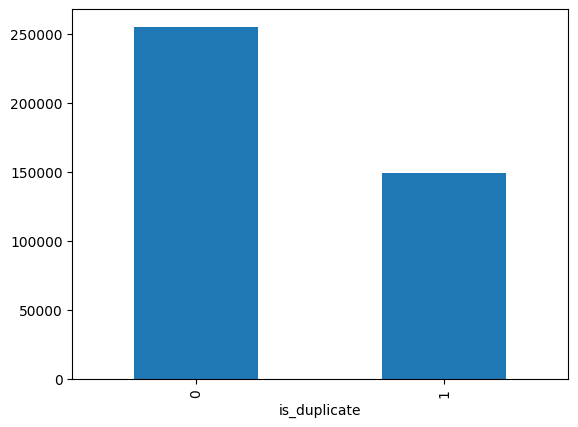

In [25]:
# Distribution of duplicate and non-duplicate questions

print(df['is_duplicate'].value_counts())
# print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)
print(df['is_duplicate'].value_counts(normalize= True) * 100)

df['is_duplicate'].value_counts().plot(kind='bar')

In [26]:
# Repeated questions

qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print('Number of unique questions', np.unique(qid).shape[0])
x = qid.value_counts()>1
print("Number of questions getting repeated", x[x].shape[0])

Number of unique questions 537933
Number of questions getting repeated 111780


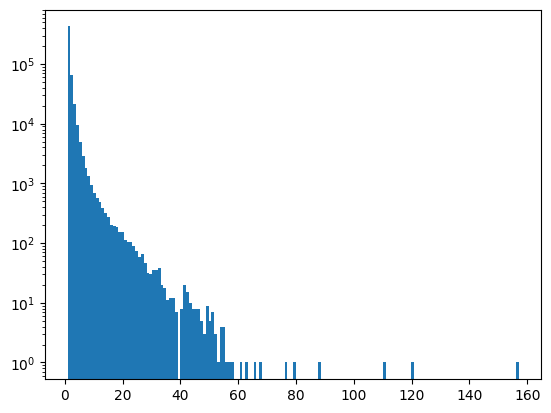

In [27]:
# Repeated questions histogram

plt.hist(qid.value_counts().values,bins=160)
plt.yscale("log")
plt.show()

Only BoW

In [28]:
df_o_bow = df.sample(30000)

In [29]:
ques_df_ob = df_o_bow[['question1', 'question2']]
ques_df_ob.head()

,question1,question2
201405,How can someone call someone else from a numbe...,How do I find out if someone else is using my ...
277077,Why do black ladybugs exist?,"How did Vietnam, Korea, and Japan emulate Chin..."
270224,What is the best question asked in your interv...,What are the best questions to ask during an i...
280073,I am a pg student. i don't have instutional ma...,How do you set up a Yahoo account?
314452,Does anyone use Quora?,Who does not use Quora?


In [30]:
ques_df_ob[["question1", "question2"]].isna().sum()

question1    0
question2    0
dtype: int64

In [31]:
ques_df_ob = ques_df_ob.dropna(subset=["question1", "question2"])

In [32]:
ques_df_ob[["question1", "question2"]].isna().sum()

question1    0
question2    0
dtype: int64

In [33]:
from sklearn.feature_extraction.text import CountVectorizer
#merge texts
questions = list(ques_df_ob['question1']) + list(ques_df_ob['question2'])

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [34]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df_ob.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df_ob.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(30000, 6000)

In [35]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
201405,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
277077,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
270224,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
280073,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
314452,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213136,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
82460,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
308015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
251989,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
temp_df['is_duplicate'] = df_o_bow['is_duplicate']

In [37]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
201405,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
277077,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
270224,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
280073,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
314452,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=1)

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7426666666666667

In [40]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7291666666666666

Bow With Basic Features

In [41]:
df_ob_wb = df_o_bow

In [42]:
# Feature Engineering

df_ob_wb['q1_len'] = df_ob_wb['question1'].str.len() 
df_ob_wb['q2_len'] = df_ob_wb['question2'].str.len()

In [43]:
df_ob_wb.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
201405,201405,303405,115985,How can someone call someone else from a numbe...,How do I find out if someone else is using my ...,0,77,67
277077,277077,396107,396108,Why do black ladybugs exist?,"How did Vietnam, Korea, and Japan emulate Chin...",0,28,148
270224,270224,78196,59734,What is the best question asked in your interv...,What are the best questions to ask during an i...,1,50,55
280073,280073,399588,366135,I am a pg student. i don't have instutional ma...,How do you set up a Yahoo account?,0,84,34
314452,314452,153643,378719,Does anyone use Quora?,Who does not use Quora?,0,22,23


In [44]:
df_ob_wb['q1_num_words'] = df_ob_wb['question1'].apply(lambda row: len(row.split(" ")))
df_ob_wb['q2_num_words'] = df_ob_wb['question2'].apply(lambda row: len(row.split(" ")))
df_ob_wb.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
201405,201405,303405,115985,How can someone call someone else from a numbe...,How do I find out if someone else is using my ...,0,77,67,15,15
277077,277077,396107,396108,Why do black ladybugs exist?,"How did Vietnam, Korea, and Japan emulate Chin...",0,28,148,5,24
270224,270224,78196,59734,What is the best question asked in your interv...,What are the best questions to ask during an i...,1,50,55,9,10
280073,280073,399588,366135,I am a pg student. i don't have instutional ma...,How do you set up a Yahoo account?,0,84,34,17,8
314452,314452,153643,378719,Does anyone use Quora?,Who does not use Quora?,0,22,23,4,5


In [46]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return len(w1 & w2)

In [47]:
df_ob_wb['word_common'] = df_ob_wb.apply(common_words, axis=1)
df_ob_wb.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
201405,201405,303405,115985,How can someone call someone else from a numbe...,How do I find out if someone else is using my ...,0,77,67,15,15,5
277077,277077,396107,396108,Why do black ladybugs exist?,"How did Vietnam, Korea, and Japan emulate Chin...",0,28,148,5,24,0
270224,270224,78196,59734,What is the best question asked in your interv...,What are the best questions to ask during an i...,1,50,55,9,10,4
280073,280073,399588,366135,I am a pg student. i don't have instutional ma...,How do you set up a Yahoo account?,0,84,34,17,8,3
314452,314452,153643,378719,Does anyone use Quora?,Who does not use Quora?,0,22,23,4,5,3


In [48]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return (len(w1) + len(w2))

In [49]:
df_ob_wb['word_total'] = df_ob_wb.apply(total_words, axis=1)
df_ob_wb.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
201405,201405,303405,115985,How can someone call someone else from a numbe...,How do I find out if someone else is using my ...,0,77,67,15,15,5,29
277077,277077,396107,396108,Why do black ladybugs exist?,"How did Vietnam, Korea, and Japan emulate Chin...",0,28,148,5,24,0,24
270224,270224,78196,59734,What is the best question asked in your interv...,What are the best questions to ask during an i...,1,50,55,9,10,4,19
280073,280073,399588,366135,I am a pg student. i don't have instutional ma...,How do you set up a Yahoo account?,0,84,34,17,8,3,23
314452,314452,153643,378719,Does anyone use Quora?,Who does not use Quora?,0,22,23,4,5,3,9


In [50]:
df_ob_wb['word_share'] = round(df_ob_wb['word_common']/df_ob_wb['word_total'],2)
df_ob_wb.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
201405,201405,303405,115985,How can someone call someone else from a numbe...,How do I find out if someone else is using my ...,0,77,67,15,15,5,29,0.17
277077,277077,396107,396108,Why do black ladybugs exist?,"How did Vietnam, Korea, and Japan emulate Chin...",0,28,148,5,24,0,24,0.00
270224,270224,78196,59734,What is the best question asked in your interv...,What are the best questions to ask during an i...,1,50,55,9,10,4,19,0.21
280073,280073,399588,366135,I am a pg student. i don't have instutional ma...,How do you set up a Yahoo account?,0,84,34,17,8,3,23,0.13
314452,314452,153643,378719,Does anyone use Quora?,Who does not use Quora?,0,22,23,4,5,3,9,0.33


minimum characters 2
maximum characters 335
average num of characters 59


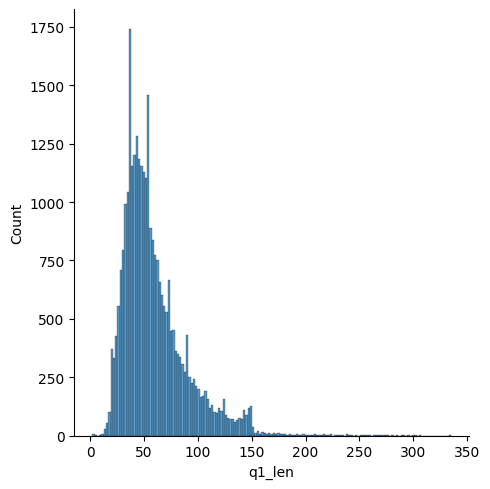

In [51]:
# Analysis of features
sns.displot(df_ob_wb['q1_len'])
print('minimum characters',df_ob_wb['q1_len'].min())
print('maximum characters',df_ob_wb['q1_len'].max())
print('average num of characters',int(df_ob_wb['q1_len'].mean()))

minimum characters 10
maximum characters 1151
average num of characters 60


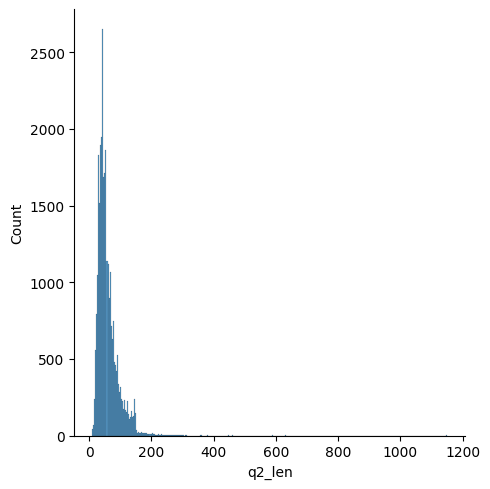

In [52]:

sns.displot(df_ob_wb['q2_len'])
print('minimum characters',df_ob_wb['q2_len'].min())
print('maximum characters',df_ob_wb['q2_len'].max())
print('average num of characters',int(df_ob_wb['q2_len'].mean()))

minimum words 1
maximum words 73
average num of words 10


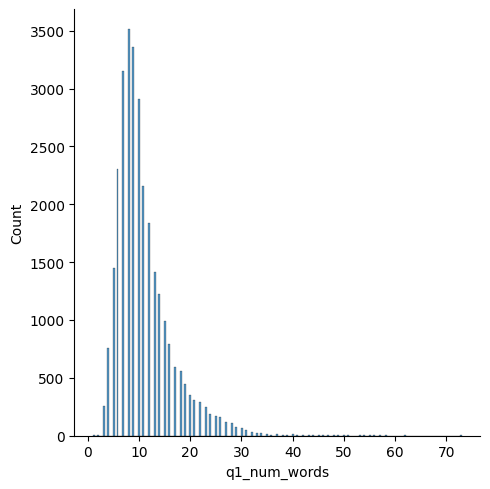

In [53]:
sns.displot(df_ob_wb['q1_num_words'])
print('minimum words',df_ob_wb['q1_num_words'].min())
print('maximum words',df_ob_wb['q1_num_words'].max())
print('average num of words',int(df_ob_wb['q1_num_words'].mean()))

minimum words 1
maximum words 237
average num of words 11


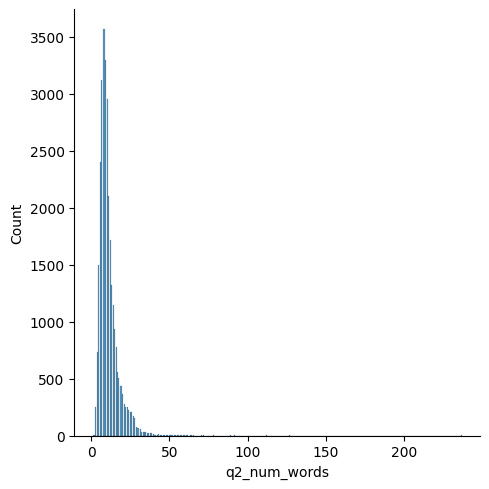

In [54]:
sns.displot(df_ob_wb['q2_num_words'])
print('minimum words',df_ob_wb['q2_num_words'].min())
print('maximum words',df_ob_wb['q2_num_words'].max())
print('average num of words',int(df_ob_wb['q2_num_words'].mean()))

/tmp/ipykernel_1070/4207929012.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_ob_wb[df_ob_wb['is_duplicate'] == 0]['word_common'],label='non duplicate')
/tmp/ipykernel_1070/4207929012.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_ob_wb[df_ob_wb['is_duplicate'] == 1]['word_common

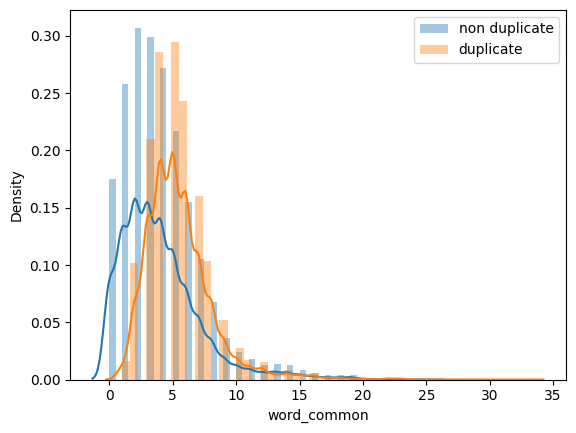

In [55]:
# common words
sns.distplot(df_ob_wb[df_ob_wb['is_duplicate'] == 0]['word_common'],label='non duplicate')
sns.distplot(df_ob_wb[df_ob_wb['is_duplicate'] == 1]['word_common'],label='duplicate')
plt.legend()
plt.show()

/tmp/ipykernel_1070/3525422978.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_ob_wb[df_ob_wb['is_duplicate'] == 0]['word_total'],label='non duplicate')
/tmp/ipykernel_1070/3525422978.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_ob_wb[df_ob_wb['is_duplicate'] == 1]['word_total']

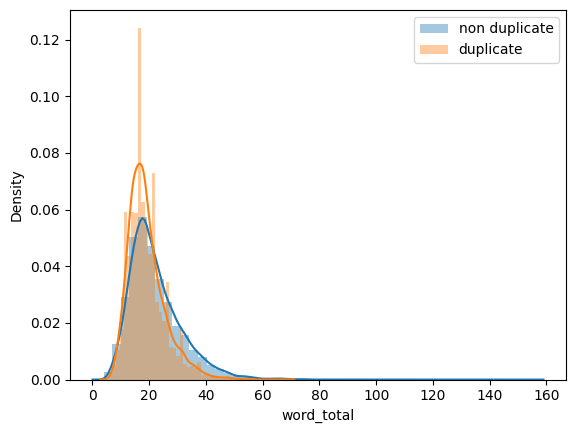

In [56]:
# total words
sns.distplot(df_ob_wb[df_ob_wb['is_duplicate'] == 0]['word_total'],label='non duplicate')
sns.distplot(df_ob_wb[df_ob_wb['is_duplicate'] == 1]['word_total'],label='duplicate')
plt.legend()
plt.show()

/tmp/ipykernel_1070/84400384.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_ob_wb[df_ob_wb['is_duplicate'] == 0]['word_share'],label='non duplicate')
/tmp/ipykernel_1070/84400384.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_ob_wb[df_ob_wb['is_duplicate'] == 1]['word_share'],lab

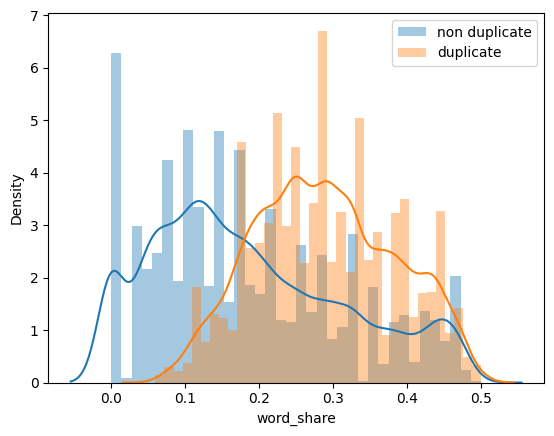

In [57]:
# word share
sns.distplot(df_ob_wb[df_ob_wb['is_duplicate'] == 0]['word_share'],label='non duplicate')
sns.distplot(df_ob_wb[df_ob_wb['is_duplicate'] == 1]['word_share'],label='duplicate')
plt.legend()
plt.show()

In [59]:
ques_df = df_ob_wb[['question1','question2']]
ques_df.head()

,question1,question2
201405,How can someone call someone else from a numbe...,How do I find out if someone else is using my ...
277077,Why do black ladybugs exist?,"How did Vietnam, Korea, and Japan emulate Chin..."
270224,What is the best question asked in your interv...,What are the best questions to ask during an i...
280073,I am a pg student. i don't have instutional ma...,How do you set up a Yahoo account?
314452,Does anyone use Quora?,Who does not use Quora?


In [60]:
final_df = df_ob_wb.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(30000, 8)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
201405,0,77,67,15,15,5,29,0.17
277077,0,28,148,5,24,0,24,0.00
270224,1,50,55,9,10,4,19,0.21
280073,0,84,34,17,8,3,23,0.13
314452,0,22,23,4,5,3,9,0.33


In [61]:
from sklearn.feature_extraction.text import CountVectorizer
# merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [62]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(30000, 6000)

In [63]:
final_df = pd.concat([final_df, temp_df], axis=1)
print(final_df.shape)
final_df.head()

(30000, 6008)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
201405,0,77,67,15,15,5,29,0.17,0,0,...,0,0,0,0,0,0,0,0,0,0
277077,0,28,148,5,24,0,24,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0
270224,1,50,55,9,10,4,19,0.21,0,0,...,0,0,0,0,0,0,0,0,0,0
280073,0,84,34,17,8,3,23,0.13,0,0,...,0,0,1,0,0,0,0,0,0,0
314452,0,22,23,4,5,3,9,0.33,0,0,...,0,0,0,0,0,0,0,0,0,0


In [64]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=1)

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.772

In [66]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7716666666666666

Advanced Features  
1. Token Features  
cwc_min: This is the ratio of the number of common words to the length of the smaller question  
cwc_max: This is the ratio of the number of common words to the length of the larger question  
csc_min: This is the ratio of the number of common stop words to the smaller stop word count among the two questions  
csc_max: This is the ratio of the number of common stop words to the larger stop word count among the two questions  
ctc_min: This is the ratio of the number of common tokens to the smaller token count among the two questions  
ctc_max: This is the ratio of the number of common tokens to the larger token count among the two questions  
last_word_eq: 1 if the last word in the two questions is same, 0 otherwise  
first_word_eq: 1 if the first word in the two questions is same, 0 otherwise  
2. Length Based Features  
mean_len: Mean of the length of the two questions (number of words)  
abs_len_diff: Absolute difference between the length of the two questions (number of words)  
longest_substr_ratio: Ratio of the length of the longest substring among the two questions to the length of the smaller question  
3. Fuzzy Features  
fuzz_ratio: fuzz_ratio score from fuzzywuzzy  
fuzz_partial_ratio: fuzz_partial_ratio from fuzzywuzzy  
token_sort_ratio: token_sort_ratio from fuzzywuzzy  
token_set_ratio: token_set_ratio from fuzzywuzzy  